# VNTS Dataset — Exploratory Data Analysis
Class frequency, tier stratification, spatial characteristics, QCVN 41 category mapping.

In [2]:
# ============================================================
# SECTION 0 — Imports & Config
# ============================================================
import os
import re
import json
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Paths — update DATASET to match your Kaggle input slug ─────────────────
DATASET = Path("/kaggle/input/datasets/maitam/vietnamese-traffic-signs/archive")
LABELS  = DATASET / "labels"
IMAGES  = DATASET / "images"
CLASSES = DATASET / "classes_en.txt"   # English names; use classes.txt or classes_vie.txt if preferred
OUT     = Path("/kaggle/working/eda_output")
OUT.mkdir(exist_ok=True, parents=True)

# NOTE: Tier thresholds are NOT set yet — we count everything first in
# Section 1, look at the percentile breakdown, and only then decide
# TIER_HIGH / TIER_MED in Section 1b below.

print(f"Dataset path exists : {DATASET.exists()}")
print(f"Images path exists  : {IMAGES.exists()}")
print(f"Labels path exists  : {LABELS.exists()}")
print(f"Classes file exists : {CLASSES.exists()}")

Dataset path exists : True
Images path exists  : True
Labels path exists  : True
Classes file exists : True


In [8]:
# ============================================================
# SECTION 1 — Load class names & count frequencies (NO tiers yet)
# ============================================================
with open(CLASSES, encoding="utf-8") as f:
    class_names = [l.strip() for l in f if l.strip()]

n_classes = len(class_names)
print(f"Classes loaded: {n_classes}")

counts = Counter()
bbox_data = []   # (class_id, cx, cy, w, h) — reused in Section 3

label_files = list(LABELS.glob("*.txt"))
print(f"Label files found: {len(label_files)}")

for lbl_file in label_files:
    with open(lbl_file, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cid, cx, cy, w, h = int(parts[0]), *map(float, parts[1:5])
            counts[cid] += 1
            bbox_data.append((cid, cx, cy, w, h))

print(f"Unique class IDs used: {len(counts)}")
print(f"Total instances: {sum(counts.values())}")

# Build summary dataframe — sorted by count, no tier column yet
df = pd.DataFrame([
    {"class_id": cid, "class_name": class_names[cid], "count": counts.get(cid, 0)}
    for cid in range(n_classes)
]).sort_values("count", ascending=False).reset_index(drop=True)

print("\n── Class Frequency Table (sorted, no tiers assigned yet) ─")
print(df.to_string(index=False))

print("\n── Percentile Breakdown ────────────────────────────────")
print(df["count"].describe())
for p in [10, 25, 50, 75, 90]:
    print(f"  {p}th percentile: {df['count'].quantile(p/100):.0f}")

Classes loaded: 52
Label files found: 3216
Unique class IDs used: 52
Total instances: 8334

── Class Frequency Table (sorted, no tiers assigned yet) ─
 class_id                                  class_name  count
       10                  No Stopping and No Parking   1071
        2                                    No Entry    470
       23            No Two or Three-wheeled Vehicles    465
       39                        Speed limit (60km/h)    459
        3                             Right Turn Only    454
       46                                  No Parking    435
       13                                   Slow Down    372
        0                         Pedestrian Crossing    312
       12                             Lane Allocation    280
       41                        Speed limit (40km/h)    275
        5       Intersection with a non-priority road    256
        7                                No Left Turn    247
       49                  No U-Turn and No Left Turn   

### Section 1b — Decide tier thresholds
Look at the percentile breakdown printed above before setting these.
A common principled choice is the 25th and 75th percentile of the
instance-count distribution — adjust `TIER_HIGH` / `TIER_MED` below
once you've inspected the numbers for THIS dataset.

In [9]:
# EDIT THESE two numbers based on the percentile printout above
TIER_HIGH = 100   # e.g. ~75th percentile
TIER_MED  = 30    # e.g. ~25th percentile

def assign_tier(n):
    if n >= TIER_HIGH: return "Frequent"
    if n >= TIER_MED:  return "Medium"
    return "Rare"

df["tier"] = df["count"].apply(assign_tier)

print(f"Thresholds set: Frequent >= {TIER_HIGH}, Medium {TIER_MED}-{TIER_HIGH-1}, Rare < {TIER_MED}")

print("\n── Class Frequency Table (with tiers) ─────────────────")
print(df.to_string(index=False))

print("\n── Tier Summary ───────────────────────────────────────")
print(df.groupby("tier")["class_name"].count().rename("num_classes").to_frame())
print(df.groupby("tier")["count"].sum().rename("total_instances").to_frame())

Thresholds set: Frequent >= 100, Medium 30-99, Rare < 30

── Class Frequency Table (with tiers) ─────────────────
 class_id                                  class_name  count     tier
       10                  No Stopping and No Parking   1071 Frequent
        2                                    No Entry    470 Frequent
       23            No Two or Three-wheeled Vehicles    465 Frequent
       39                        Speed limit (60km/h)    459 Frequent
        3                             Right Turn Only    454 Frequent
       46                                  No Parking    435 Frequent
       13                                   Slow Down    372 Frequent
        0                         Pedestrian Crossing    312 Frequent
       12                             Lane Allocation    280 Frequent
       41                        Speed limit (40km/h)    275 Frequent
        5       Intersection with a non-priority road    256 Frequent
        7                                No Le

In [10]:
# ============================================================
# SECTION 2 — QCVN 41 Hierarchical Category Mapping
# ============================================================
# B.8a (ID 34) -> Prohibitory (P.108a, "Cam xe so-mi ro-mooc")
# Camera (ID 31) -> Information

CATEGORY_MAPPING = {
    # Prohibitory (0) — 23 classes
    2:0, 7:0, 10:0, 14:0, 16:0, 17:0, 18:0, 19:0, 20:0,
    23:0, 24:0, 29:0, 32:0, 34:0, 35:0, 36:0, 38:0, 39:0,
    40:0, 41:0, 46:0, 47:0, 49:0,
    # Warning (1) — 18 classes
    0:1, 1:1, 4:1, 5:1, 6:1, 13:1, 15:1, 21:1, 22:1,
    26:1, 27:1, 33:1, 37:1, 43:1, 44:1, 48:1, 50:1, 51:1,
    # Mandatory (2) — 4 classes
    3:2, 9:2, 12:2, 42:2,
    # Information (3) — 4 classes
    8:3, 11:3, 31:3, 45:3,
    # Supplementary (4) — 3 classes
    25:4, 28:4, 30:4,
}

CATEGORY_NAMES = {
    0: "Prohibitory",
    1: "Warning",
    2: "Mandatory",
    3: "Information",
    4: "Supplementary",
}

# ── Verify all class IDs are mapped ─────────────────────────────
all_ids = set(range(n_classes))
mapped  = set(CATEGORY_MAPPING.keys())
missing = all_ids - mapped
if missing:
    print(f"WARNING — unmapped class IDs: {sorted(missing)}")
else:
    print(f"All {n_classes} class IDs mapped to QCVN 41 categories")

df["category_id"] = df["class_id"].map(CATEGORY_MAPPING)
df["category_name"] = df["category_id"].map(CATEGORY_NAMES)

print("\n── Instance Distribution Across QCVN 41 Categories ─────")
cat_summary = df.groupby("category_name").agg(
    classes=("class_name", "count"),
    instances=("count", "sum")
).reindex(["Prohibitory", "Warning", "Mandatory", "Information", "Supplementary"])
cat_summary["pct_of_total"] = (cat_summary["instances"] / cat_summary["instances"].sum() * 100).round(1)
print(cat_summary.to_string())

cat_summary.to_csv(OUT / "category_summary.csv")

All 52 class IDs mapped to QCVN 41 categories

── Instance Distribution Across QCVN 41 Categories ─────
               classes  instances  pct_of_total
category_name                                  
Prohibitory         23       5147          61.8
Warning             18       1727          20.7
Mandatory            4        798           9.6
Information          4        472           5.7
Supplementary        3        190           2.3


In [11]:
# ============================================================
# SECTION 3 — Plots
# ============================================================
TIER_COLORS = {"Frequent": "#2196F3", "Medium": "#FF9800", "Rare": "#F44336"}

def save(fig, name):
    p = OUT / name
    fig.savefig(p, dpi=150, bbox_inches="tight")
    print(f"Saved -> {p}")
    plt.close(fig)

# ── Plot 1: Full class distribution, color-coded by tier ───────
fig, ax = plt.subplots(figsize=(18, 6))
colors = [TIER_COLORS[t] for t in df["tier"]]
ax.bar(df["class_name"], df["count"], color=colors, edgecolor="white", linewidth=0.4)
ax.set_xticklabels(df["class_name"], rotation=90, fontsize=7)
ax.set_ylabel("Instance count")
ax.set_title("Class Distribution — All 52 Categories (color = tier)")
patches = [mpatches.Patch(color=v, label=k) for k, v in TIER_COLORS.items()]
ax.legend(handles=patches)
ax.axhline(TIER_HIGH, color="#2196F3", linestyle="--", linewidth=0.8, alpha=0.5)
ax.axhline(TIER_MED,  color="#FF9800", linestyle="--", linewidth=0.8, alpha=0.5)
save(fig, "plot1_class_distribution.png")

# ── Plot 2: Top 10 / Bottom 10 ──────────────────────────────────
top10    = df.head(10)
bottom10 = df.tail(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, subset, title in zip(axes, [top10, bottom10],
                              ["Top 10 Most Frequent Classes", "Bottom 10 Rarest Classes"]):
    ax.barh(subset["class_name"], subset["count"], color=[TIER_COLORS[t] for t in subset["tier"]])
    ax.invert_yaxis()
    ax.set_xlabel("Instance count")
    ax.set_title(title)
fig.suptitle("Frequency Extremes", fontsize=13)
save(fig, "plot2_top_bottom10.png")

# ── Plot 3: Bounding box spatial analysis ───────────────────────
bbox_df = pd.DataFrame(bbox_data, columns=["class_id", "cx", "cy", "w", "h"])
bbox_df["area"] = bbox_df["w"] * bbox_df["h"]
bbox_df["tier"] = bbox_df["class_id"].map(dict(zip(df["class_id"], df["tier"])))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(bbox_df["w"], bins=50, color="#607D8B")
axes[0].set_title("BBox Width (relative)")
axes[1].hist(bbox_df["h"], bins=50, color="#607D8B")
axes[1].set_title("BBox Height (relative)")
axes[2].hist(bbox_df["area"], bins=50, color="#607D8B")
axes[2].axvline(0.03, color="red", linestyle="--", label="3% area")
axes[2].set_title("BBox Area (fraction of image)")
axes[2].legend()
fig.suptitle("Bounding Box Spatial Characteristics", fontsize=13)
save(fig, "plot3_spatial_characteristics.png")

# ── Plot 4: Area distribution split by tier ─────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for tier in ["Frequent", "Medium", "Rare"]:
    subset = bbox_df[bbox_df["tier"] == tier]["area"]
    if not subset.empty:
        ax.hist(subset, bins=40, alpha=0.6, label=f"{tier} (n={len(subset)})", color=TIER_COLORS[tier])
ax.set_xlabel("BBox area (fraction of image)")
ax.set_title("BBox Area Distribution by Tier")
ax.legend()
save(fig, "plot4_area_by_tier.png")

# ── Plot 5: Object density per image ────────────────────────────
density = Counter()
for lbl_file in label_files:
    with open(lbl_file, encoding="utf-8") as f:
        density[lbl_file.stem] = sum(1 for l in f if l.strip())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(list(density.values()), bins=range(1, max(density.values()) + 2), color="#9C27B0", edgecolor="white")
ax.set_xlabel("Objects per image")
ax.set_ylabel("Number of images")
ax.set_title("Object Density Distribution")
save(fig, "plot5_object_density.png")

print(f"\nAverage objects per image: {np.mean(list(density.values())):.2f}")
print("All plots saved to:", OUT)

/tmp/ipykernel_58/2497170563.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["class_name"], rotation=90, fontsize=7)


Saved -> /kaggle/working/eda_output/plot1_class_distribution.png
Saved -> /kaggle/working/eda_output/plot2_top_bottom10.png
Saved -> /kaggle/working/eda_output/plot3_spatial_characteristics.png
Saved -> /kaggle/working/eda_output/plot4_area_by_tier.png
Saved -> /kaggle/working/eda_output/plot5_object_density.png

Average objects per image: 2.59
All plots saved to: /kaggle/working/eda_output


In [12]:
# ============================================================
# SECTION 4 — Summary Tables
# ============================================================
tier_order = ["Frequent", "Medium", "Rare"]

tier_summary = df.groupby("tier").agg(
    num_classes=("class_name", "count"),
    total_instances=("count", "sum"),
    min_instances=("count", "min"),
    max_instances=("count", "max"),
    median_instances=("count", "median")
).reindex(tier_order)

print("── Tier Summary Table ─────────────────────────────────")
print(tier_summary.to_string())
tier_summary.to_csv(OUT / "tier_summary.csv")

spatial_summary = bbox_df.groupby("tier")["area"].agg(
    mean_area="mean", median_area="median", min_area="min", max_area="max"
).reindex(tier_order)

print("\n── Spatial Summary by Tier ────────────────────────────")
print(spatial_summary.to_string())
spatial_summary.to_csv(OUT / "spatial_summary.csv")

df.to_csv(OUT / "class_frequency_table.csv", index=False)

print("\n── Dataset Overview ───────────────────────────────────")
print(f"Total images         : {len(label_files)}")
print(f"Total instances       : {sum(counts.values())}")
print(f"Total classes         : {n_classes}")
print(f"Avg objects per image : {np.mean(list(density.values())):.2f}")
print(f"\nAll tables saved to: {OUT}")

── Tier Summary Table ─────────────────────────────────
          num_classes  total_instances  min_instances  max_instances  median_instances
tier                                                                                  
Frequent           24             7201            105           1071             234.0
Medium             15              873             33             87              52.0
Rare               13              260              3             29              22.0

── Spatial Summary by Tier ────────────────────────────
          mean_area  median_area  min_area  max_area
tier                                                
Frequent   0.003633     0.001404  0.000075  0.113179
Medium     0.005739     0.002431  0.000154  0.123457
Rare       0.003860     0.001873  0.000326  0.033785

── Dataset Overview ───────────────────────────────────
Total images         : 3216
Total instances       : 8334
Total classes         : 52
Avg objects per image : 2.59

All tables saved

In [13]:
# ============================================================
# SECTION 5 — Save all outputs as a zip for download
# ============================================================
import shutil

shutil.make_archive("/kaggle/working/eda_outputs", "zip", str(OUT))
print("EDA outputs zipped -> /kaggle/working/eda_outputs.zip")
print("Download from the Output tab after committing this notebook.")

EDA outputs zipped -> /kaggle/working/eda_outputs.zip
Download from the Output tab after committing this notebook.


── plot1_class_distribution.png ──


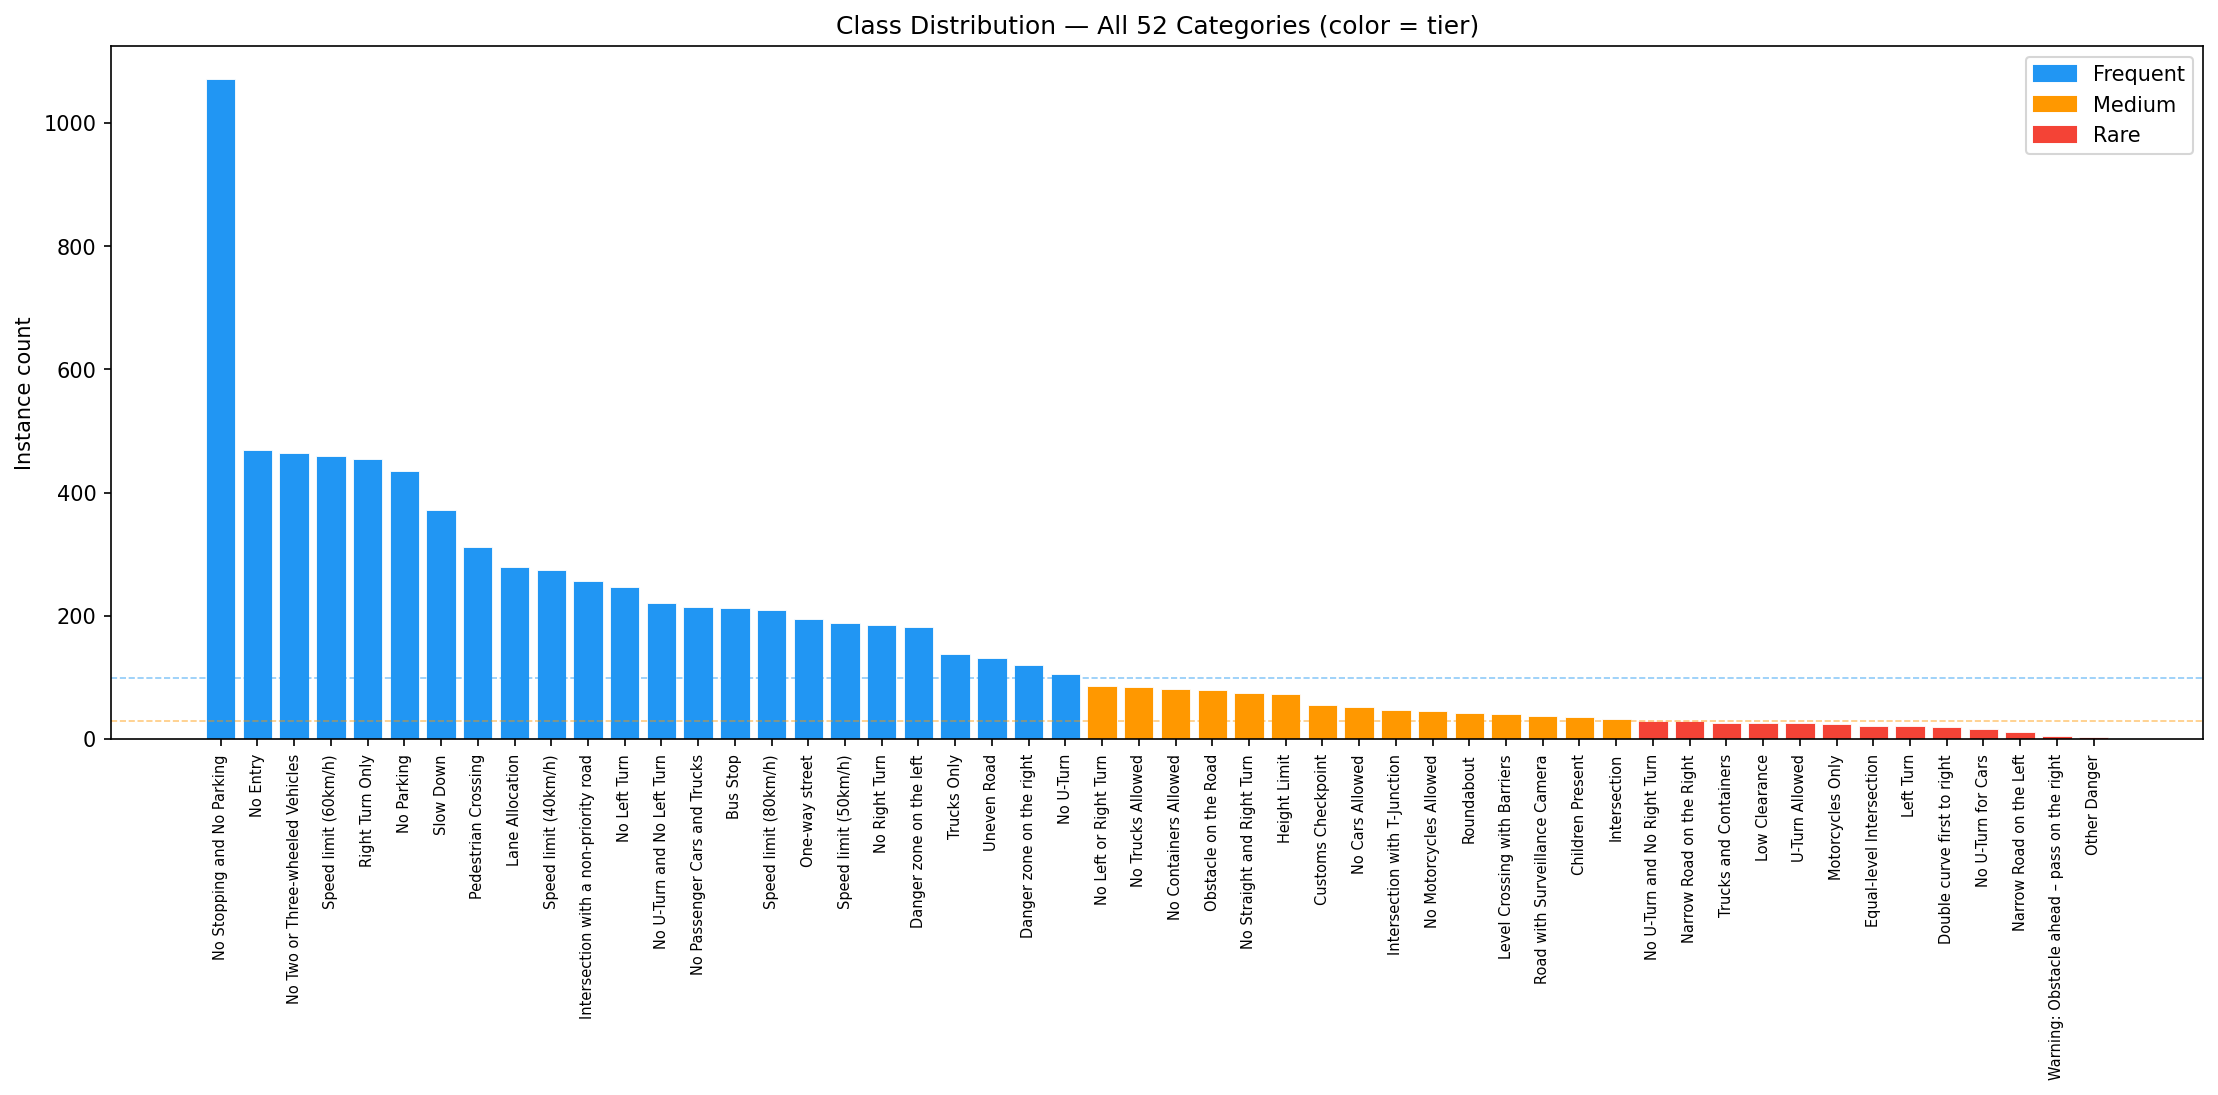

── plot2_top_bottom10.png ──


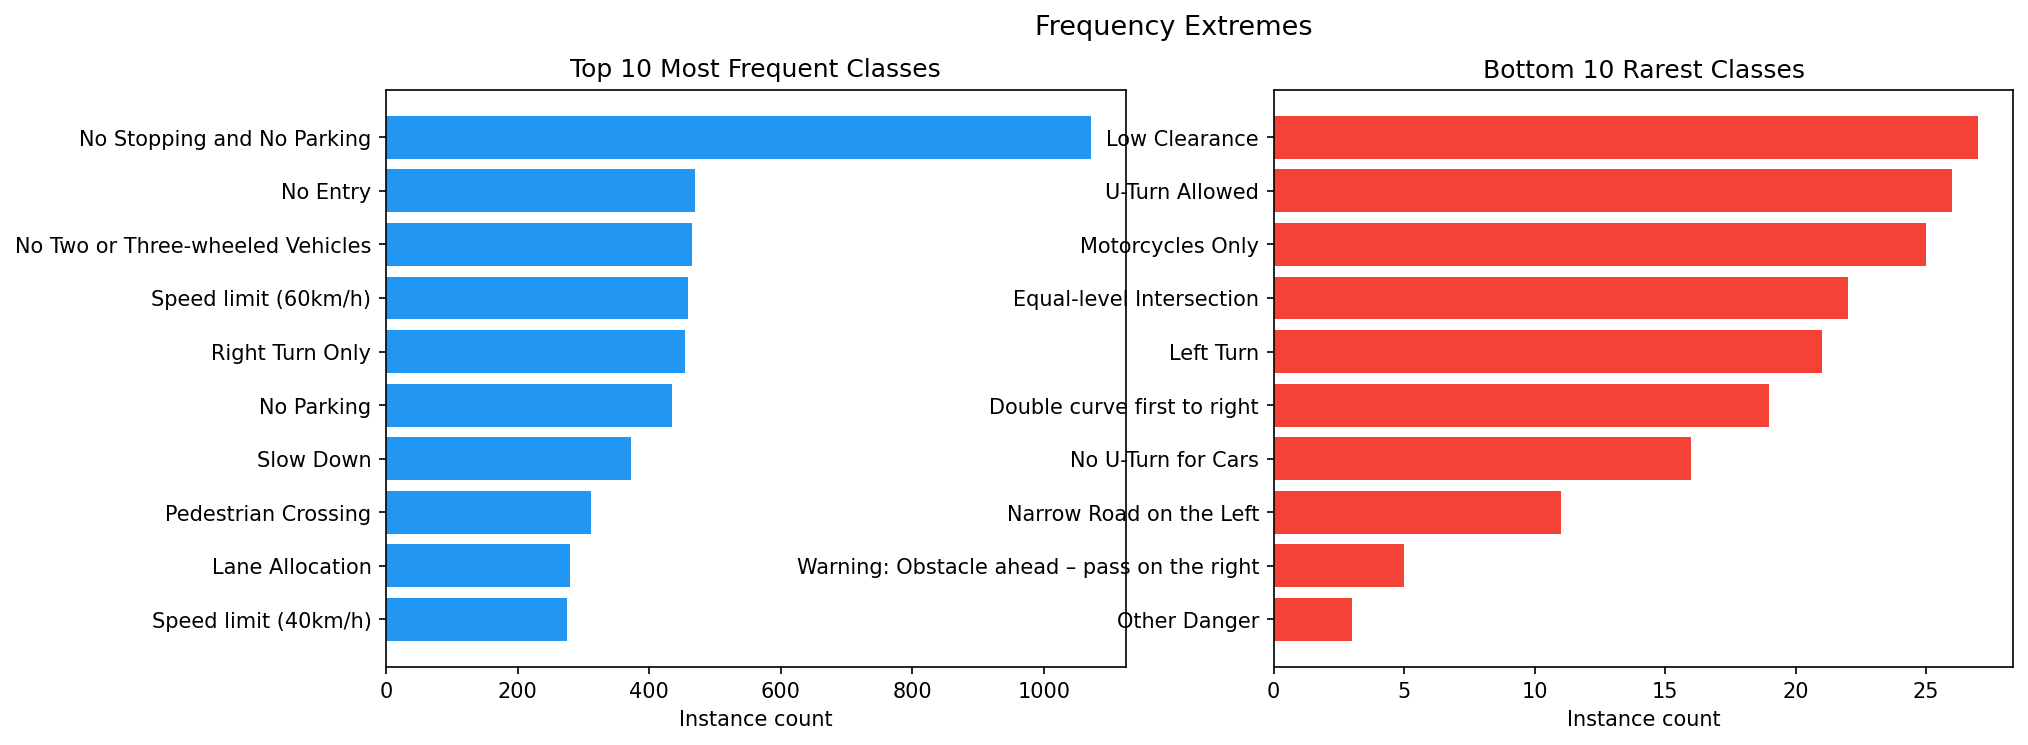

── plot3_spatial_characteristics.png ──


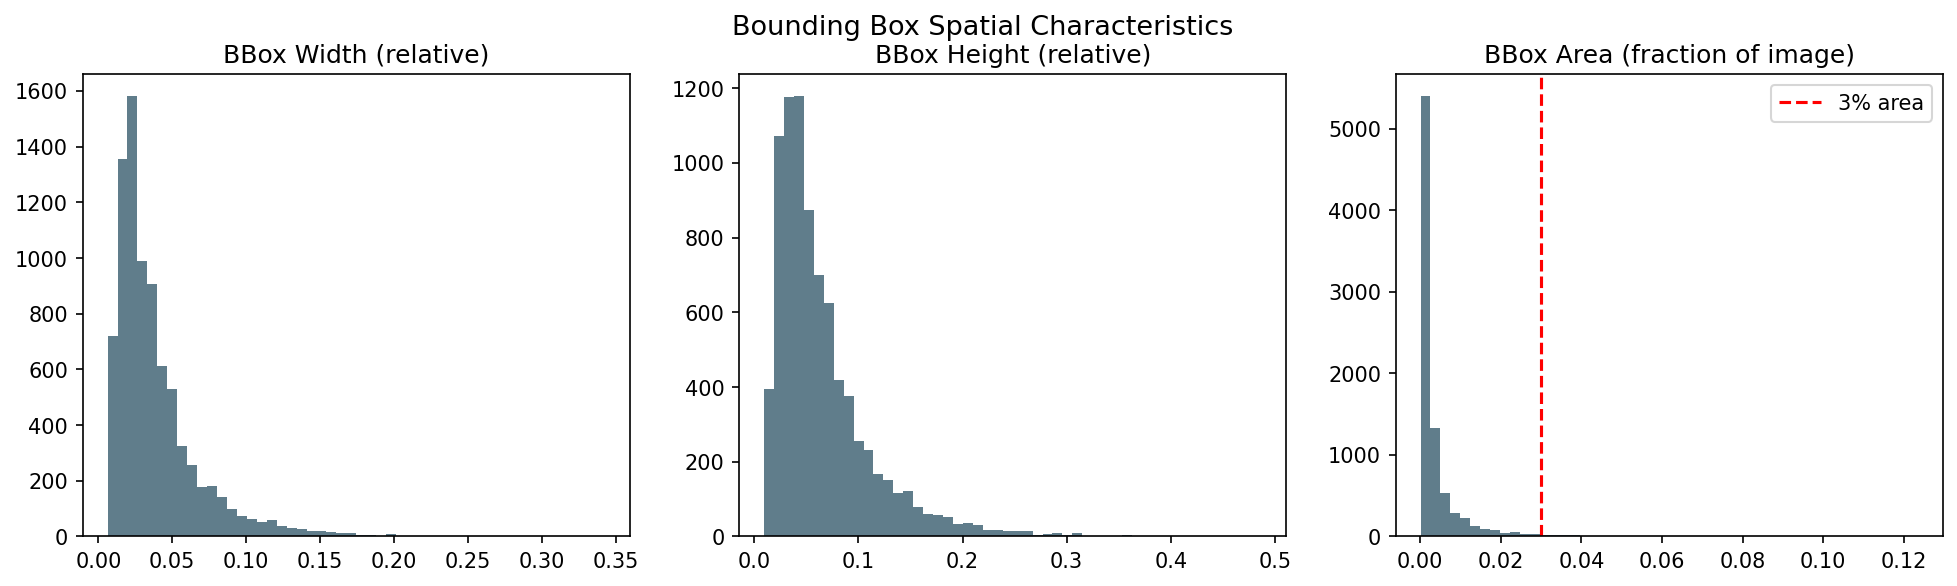

── plot4_area_by_tier.png ──


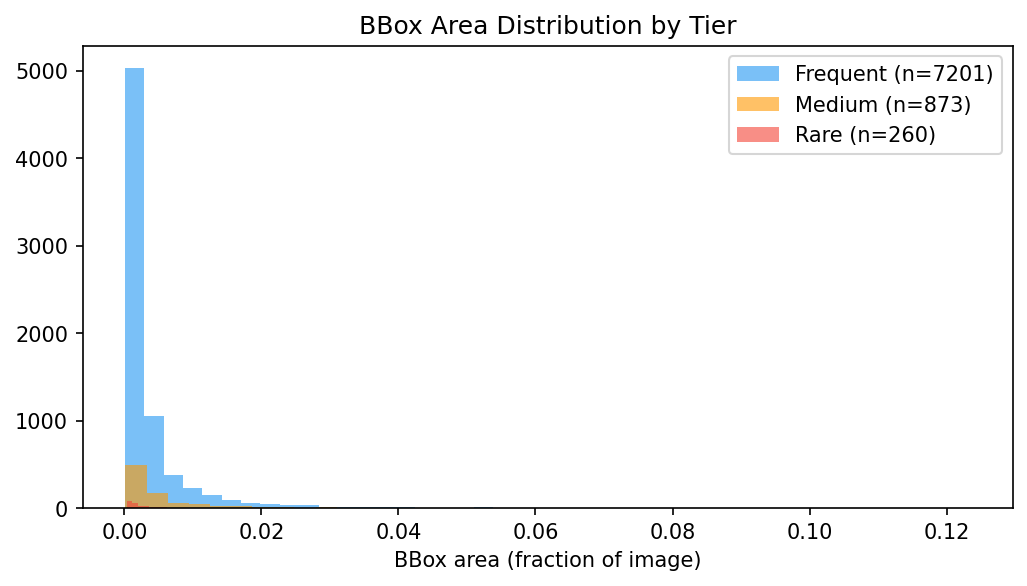

── plot5_object_density.png ──


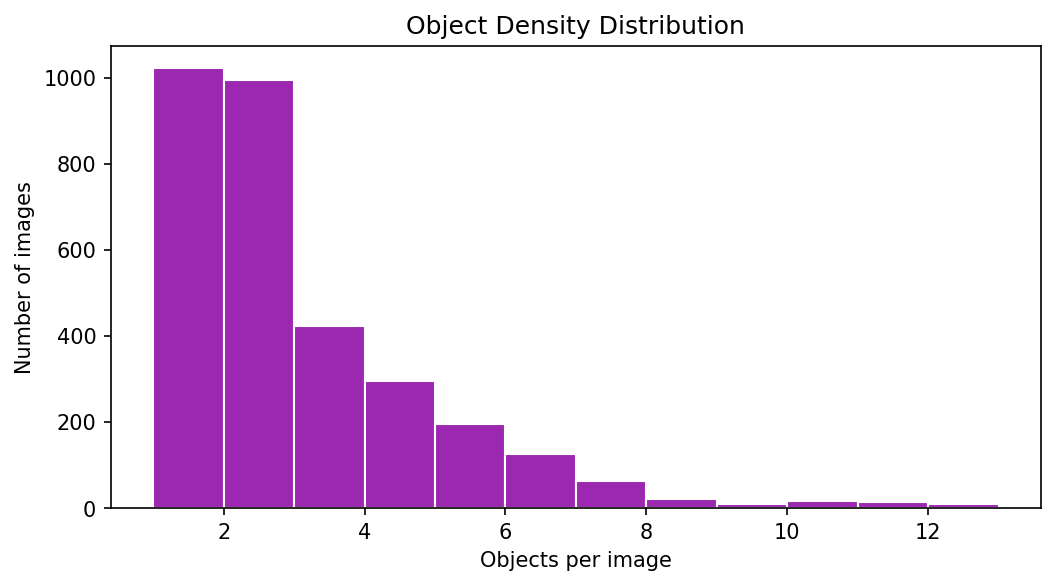

In [14]:
# ============================================================
# SECTION 6 — Display all saved plots inline
# ============================================================
from IPython.display import Image, display

plot_files = [
    "plot1_class_distribution.png",
    "plot2_top_bottom10.png",
    "plot3_spatial_characteristics.png",
    "plot4_area_by_tier.png",
    "plot5_object_density.png",
]

for fname in plot_files:
    fpath = OUT / fname
    print(f"── {fname} ──")
    display(Image(filename=str(fpath)))

## EDA Summary

The VNTS dataset contains 3,216 images and 8,334 annotated instances 
across 52 traffic sign classes, averaging 2.59 objects per image.

**Class imbalance.** Instance counts range from 1,071 (No Stopping and 
No Parking) down to 3 (rarest class), producing a severe long-tail 
distribution. Using the 25th and 75th percentiles of the count 
distribution as principled cutoffs, classes were split into three 
frequency tiers:

| Tier | Classes | Instances | Min | Median | Max |
|------|---------|-----------|-----|--------|-----|
| Frequent (≥100) | 24 | 7,201 | 105 | 234 | 1,071 |
| Medium (30–99) | 15 | 873 | 33 | 52 | 87 |
| Rare (<30) | 13 | 260 | 3 | 22 | 29 |

The Frequent tier alone accounts for 86.4% of all instances.

**Object scale.** Median bounding box area stays under 0.25% of image 
area across all three tiers (Frequent 0.0014, Medium 0.0024, Rare 
0.0019), confirming that object scale does not confound tier-based 
performance comparisons — signs are small regardless of class frequency.

**QCVN 41 category distribution.** Mapping all 52 classes to their 
five QCVN 41 Level-1 categories shows further imbalance at the 
category level: Prohibitory signs dominate at 61.8% of instances (23 
classes), followed by Warning (20.7%, 18 classes), Mandatory (9.6%, 4 
classes), Information (5.7%, 4 classes), and Supplementary (2.3%, 3 
classes).

**Implication.** These findings motivate the stratified per-class 
evaluation used later in this study, and establish that any 
performance gap between frequency tiers cannot be attributed to 
differences in object scale.

In [3]:
import sys

# List of all third-party libraries used across your 3 notebooks
libraries = [
    "wandb",
    "kaggle_secrets",
    "torch",
    "ultralytics",
    "numpy",
    "pandas",
    "matplotlib",
    "scipy",
    "seaborn",
    "yaml"  # Imported as 'yaml', but packaged as 'pyyaml'
]

print("=== Copy these versions for your requirements.txt ===\n")

for lib in libraries:
    try:
        # Dynamically import the module
        module = __import__(lib)
        
        # Determine the correct requirements.txt package name
        req_name = "pyyaml" if lib == "yaml" else lib
        
        # Grab the version attribute
        if hasattr(module, "__version__"):
            print(f"{req_name}=={module.__version__}")
        elif hasattr(module, "version"):
            print(f"{req_name}=={module.version}")
        else:
            print(f"{req_name}==[Version not found dynamically, check manually]")
            
    except ImportError:
        # Handle cases where a library might not be installed in the current notebook environment
        print(f"{lib}==[Not installed in this environment]")

=== Copy these versions for your requirements.txt ===

wandb==0.26.1
kaggle_secrets==[Version not found dynamically, check manually]
torch==2.10.0+cpu
ultralytics==[Not installed in this environment]
numpy==2.0.2
pandas==2.3.3
matplotlib==3.10.0
scipy==1.16.3
seaborn==0.13.2
pyyaml==6.0.3
